# recs_012 — Causal training rows + smoke two-tower (explore)

**Roadmap (once this design wins):** Build a pipeline to **train and export** two-tower weights and **precomputed item-side vectors**; then a small runtime path that turns each eval example into a **query vector** and dots against that matrix; then register a **new method** in `retrieval_offline_eval` so metrics match the **same contract** as the existing baselines (same examples, masking, catalog order—only the scorer changes).

**Goal:** **One row per anchor** on the train split: `(ts, review_id)` total order, thumbs-up labels only, **`anchor_review_text`** included. Optional **Parquet** snapshot. **Smoke two-tower:** frozen USE + frozen item row → trainable `Dense` projections + symmetric in-batch softmax (TensorFlow).

**Edit one place:** the `Recs012Config` dataclass in the next cell (paths, caps, seeds, tower hyperparameters).

| Anchor style | Notes |
|----------------|-------|
| **Per-review (default)** | State = thumbs-up with `(ts, rid)` strictly before anchor; labels = distinct apps from strictly after. |
| **Fixed cutoff / random cut** | Not implemented here; add later if needed. |

**Scale:** `max_users_anchor=None` materializes all users with ≥1 thumbs-up (slow / large). Use an integer for dev.


In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from steam_review_ml.data.loaders import (
    NORMALIZED_SPLIT_FILENAMES,
    SPLIT_TRAIN,
    SPLIT_VAL,
    load_normalized_split_df,
    resolve_normalized_split_parquet,
)
from steam_review_ml.evaluation.retrieval_offline_eval import USER_COL
from steam_review_ml.recommender.retrieve import ContentRetriever


def find_repo_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for parent_dir in (here, *here.parents):
        if (parent_dir / "pyproject.toml").is_file():
            return parent_dir
    raise RuntimeError(f"No pyproject.toml above {here}")


@dataclass
class Recs012Config:
    """Single place to tune this notebook (no scattered globals)."""

    repo_root: Path = field(default_factory=lambda: find_repo_root())
    min_review_chars: int = 30
    # None = all users with ≥1 train thumbs-up; int = random subset of users (speed)
    max_users_anchor: int | None = 20_000
    random_seed: int = 2026
    write_anchors_parquet: bool = False
    anchors_parquet_relative: str = "artifacts/recs/training_rows/anchors_per_review_train.parquet"
    # --- smoke two-tower ---
    max_rows_tower: int = 1024
    batch_size: int = 64
    proj_dim: int = 64
    temperature: float = 0.07
    n_train_steps: int = 100
    tower_seed: int = 2026
    adam_lr: float = 1e-3

    @property
    def train_parquet(self) -> Path:
        return self.repo_root / "data" / "processed" / NORMALIZED_SPLIT_FILENAMES["train"]

    @property
    def anchors_parquet_path(self) -> Path:
        return self.repo_root / Path(self.anchors_parquet_relative)


CFG = Recs012Config()
processed_data_dir = CFG.repo_root / "data" / "processed"
val_parquet_path, val_split_resolved = resolve_normalized_split_parquet(processed_data_dir, SPLIT_VAL)
print("repo_root:", CFG.repo_root)
print("train_parquet exists:", CFG.train_parquet.is_file(), CFG.train_parquet)
print(
    "val parquet (resolved):",
    val_split_resolved,
    val_parquet_path.is_file(),
    val_parquet_path,
)


/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo_root: /home/ryanr/workspace/steam_recommendations
train_parquet exists: True /home/ryanr/workspace/steam_recommendations/data/processed/steam_reviews_cleaned_english_train_norm.parquet
val parquet (resolved): val True /home/ryanr/workspace/steam_recommendations/data/processed/steam_reviews_cleaned_english_val_norm.parquet


In [2]:
def load_retriever_and_train(cfg: Recs012Config) -> tuple[ContentRetriever, pd.DataFrame]:
    """ContentRetriever (indexed apps) + filtered train split (same contract as offline eval)."""
    retriever = ContentRetriever(repo_root=cfg.repo_root)
    indexed_app_ids = set(int(app_id) for app_id in retriever.app_ids.tolist())
    if not cfg.train_parquet.is_file():
        raise FileNotFoundError(cfg.train_parquet)
    train_reviews = load_normalized_split_df(
        cfg.train_parquet,
        indexed_apps=indexed_app_ids,
        min_review_chars=cfg.min_review_chars,
        user_col=USER_COL,
    )
    return retriever, train_reviews


retriever, df_train = load_retriever_and_train(CFG)
indexed_app_ids = set(int(app_id) for app_id in retriever.app_ids.tolist())
if not val_parquet_path.is_file():
    raise FileNotFoundError(val_parquet_path)
df_val = load_normalized_split_df(
    val_parquet_path,
    indexed_apps=indexed_app_ids,
    min_review_chars=CFG.min_review_chars,
    user_col=USER_COL,
)
print(
    "indexed apps:",
    len(retriever.app_ids),
    "\ntrain rows:",
    len(df_train),
    "users:",
    df_train[USER_COL].nunique(),
)
print(
    f"val split resolved as {val_split_resolved!r}: rows={len(df_val):,} users={df_val[USER_COL].nunique():,}",
)


indexed apps: 315 
train rows: 3878131 users: 2819661
val split resolved as 'val': rows=1,617,344 users=1,291,474


In [3]:
def strictly_before(
    timestamp_series: pd.Series,
    review_id_series: pd.Series,
    anchor_timestamp: float,
    anchor_review_id: int,
) -> pd.Series:
    return (timestamp_series < anchor_timestamp) | (
        (timestamp_series == anchor_timestamp) & (review_id_series < anchor_review_id)
    )


def strictly_after(
    timestamp_series: pd.Series,
    review_id_series: pd.Series,
    anchor_timestamp: float,
    anchor_review_id: int,
) -> pd.Series:
    return (timestamp_series > anchor_timestamp) | (
        (timestamp_series == anchor_timestamp) & (review_id_series > anchor_review_id)
    )


def materialize_per_review_anchors(
    train_reviews: pd.DataFrame,
    *,
    user_col: str = USER_COL,
    max_users: int | None,
    rng: np.random.Generator,
    show_progress: bool = True,
) -> pd.DataFrame:
    positive_only = train_reviews.loc[train_reviews["recommended"] == 1].copy()
    if positive_only.empty:
        return pd.DataFrame()
    unique_users_with_positive = positive_only[user_col].unique()
    if max_users is not None and max_users > 0 and len(unique_users_with_positive) > max_users:
        sampled_user_ids = rng.choice(unique_users_with_positive, size=int(max_users), replace=False)
        positive_only = positive_only.loc[positive_only[user_col].isin(sampled_user_ids)]
    sort_columns = ["ts", "review_id"]
    anchor_records: list[dict] = []
    reviews_grouped_by_user = positive_only.groupby(user_col, sort=False)
    num_users_for_progress = int(positive_only[user_col].nunique())
    user_iterator = (
        tqdm(reviews_grouped_by_user, total=num_users_for_progress, desc="anchors")
        if show_progress
        else reviews_grouped_by_user
    )
    for steam_user_id, positive_anchor_rows in user_iterator:
        user_sorted_reviews = train_reviews.loc[train_reviews[user_col] == steam_user_id].sort_values(
            sort_columns, kind="mergesort"
        )
        sorted_positive_anchors = positive_anchor_rows.sort_values(sort_columns, kind="mergesort")
        for _, anchor_row in sorted_positive_anchors.iterrows():
            anchor_timestamp = float(anchor_row["ts"])
            anchor_review_id = int(anchor_row["review_id"])
            user_timestamp_series = user_sorted_reviews["ts"]
            user_review_id_series = user_sorted_reviews["review_id"]
            prior_positive_mask = strictly_before(
                user_timestamp_series,
                user_review_id_series,
                anchor_timestamp,
                anchor_review_id,
            ) & (user_sorted_reviews["recommended"] == 1)
            future_positive_mask = strictly_after(
                user_timestamp_series,
                user_review_id_series,
                anchor_timestamp,
                anchor_review_id,
            ) & (user_sorted_reviews["recommended"] == 1)
            prior_positive_reviews = user_sorted_reviews.loc[prior_positive_mask]
            future_positive_reviews = user_sorted_reviews.loc[future_positive_mask]
            future_positive_app_ids_sorted = sorted(
                {int(app_id) for app_id in future_positive_reviews["app_id"].tolist()}
            )
            anchor_records.append(
                {
                    user_col: steam_user_id,
                    "anchor_review_id": anchor_review_id,
                    "anchor_ts": anchor_timestamp,
                    "anchor_app_id": int(anchor_row["app_id"]),
                    "anchor_review_text": str(anchor_row["review"]),
                    "n_state_pos_reviews": int(len(prior_positive_reviews)),
                    "n_future_pos_apps": int(len(future_positive_app_ids_sorted)),
                    "future_positive_app_ids": future_positive_app_ids_sorted,
                }
            )
    return pd.DataFrame(anchor_records)


def assert_causal_invariants(
    anchors_df: pd.DataFrame,
    train_reviews: pd.DataFrame,
    *,
    user_col: str = USER_COL,
    random_state: int,
) -> None:
    if anchors_df.empty:
        return
    sample_rows = anchors_df.sample(n=min(25, len(anchors_df)), random_state=random_state)
    for record in sample_rows.to_dict(orient="records"):
        steam_user_id = record[user_col]
        anchor_timestamp = float(record["anchor_ts"])
        anchor_review_id = int(record["anchor_review_id"])
        user_reviews = train_reviews.loc[train_reviews[user_col] == steam_user_id]
        assert (user_reviews.loc[user_reviews["review_id"] == anchor_review_id, "ts"] == anchor_timestamp).all()
        anchor_text_from_split = user_reviews.loc[user_reviews["review_id"] == anchor_review_id, "review"].iloc[0]
        assert str(anchor_text_from_split) == str(record["anchor_review_text"])
        user_timestamp_series = user_reviews["ts"]
        user_review_id_series = user_reviews["review_id"]
        future_positive_reviews = user_reviews.loc[
            strictly_after(user_timestamp_series, user_review_id_series, anchor_timestamp, anchor_review_id)
            & (user_reviews["recommended"] == 1)
        ]
        future_app_ids_from_split = {int(app_id) for app_id in future_positive_reviews["app_id"]}
        assert future_app_ids_from_split == set(record["future_positive_app_ids"])
        prior_positive_reviews = user_reviews.loc[
            strictly_before(user_timestamp_series, user_review_id_series, anchor_timestamp, anchor_review_id)
            & (user_reviews["recommended"] == 1)
        ]
        assert prior_positive_reviews.empty or strictly_before(
            prior_positive_reviews["ts"],
            prior_positive_reviews["review_id"],
            anchor_timestamp,
            anchor_review_id,
        ).all()


def maybe_write_anchors(anchors_df: pd.DataFrame, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    anchors_df.to_parquet(output_path, index=False)
    print("wrote", output_path)


rng_anchor = np.random.default_rng(CFG.random_seed)
anchors = materialize_per_review_anchors(
    df_train,
    max_users=CFG.max_users_anchor,
    rng=rng_anchor,
    show_progress=True,
)
print("anchor rows:", len(anchors), "with ≥1 future app:", int((anchors["n_future_pos_apps"] > 0).sum()))
print(anchors.head())

assert_causal_invariants(anchors, df_train, random_state=CFG.random_seed)
print("invariant spot-check (train): OK")

rng_anchor_val = np.random.default_rng(int(CFG.random_seed) + 903_571)
anchors_val = materialize_per_review_anchors(
    df_val,
    max_users=CFG.max_users_anchor,
    rng=rng_anchor_val,
    show_progress=True,
)
print(
    "val anchor rows:",
    len(anchors_val),
    "with ≥1 future app:",
    int((anchors_val["n_future_pos_apps"] > 0).sum()),
)
assert_causal_invariants(anchors_val, df_val, random_state=CFG.random_seed)
print("invariant spot-check (val): OK")

if CFG.write_anchors_parquet:
    maybe_write_anchors(anchors, CFG.anchors_parquet_path)


anchors: 100%|██████████| 20000/20000 [05:47<00:00, 57.49it/s]


anchor rows: 26847 with ≥1 future app: 6847
      author.steamid  anchor_review_id     anchor_ts  anchor_app_id  \
0  76561198210938431          84439221  1.610297e+09         292030   
1  76561198046126525          84016485  1.609792e+09         292030   
2  76561198983434400          83537887  1.609303e+09         292030   
3  76561198027918803          83152344  1.608938e+09         292030   
4  76561198029457314          81468869  1.606923e+09         292030   

                                  anchor_review_text  n_state_pos_reviews  \
0  Amazing game, I beat it on the PS4 and immedia...                    0   
1      Best cardgame ever, not a bad subplot either.                    0   
2                  Fun game worth it would recommend                    0   
3  You will never play another game like this eve...                    0   
4  First Witcher game, introduced by friend, and ...                    0   

   n_future_pos_apps future_positive_app_ids  
0                  

anchors:  45%|████▍     | 8971/20000 [01:11<01:31, 120.17it/s]anchors: 100%|██████████| 20000/20000 [02:44<00:00, 121.24it/s]


val anchor rows: 24188 with ≥1 future app: 4188
invariant spot-check (val): OK


[train] fraction n_future_pos_apps == 0: 0.7449621931686967
[train] users with exactly 1 train thumbs-up (among anchor users): 17510/20000
[train] anchors with ≥1 future app: 6847/26847


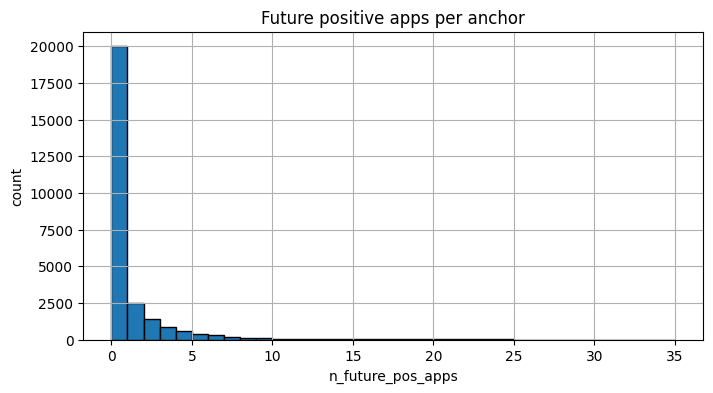

[val] fraction n_future_pos_apps == 0: 0.826856292376385
[val] users with exactly 1 val thumbs-up (among anchor users): 15989/20000
[val] anchors with ≥1 future app: 4188/24188


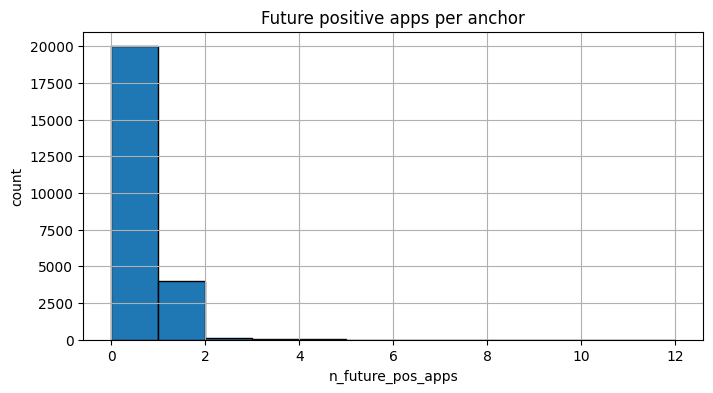

In [4]:
def summarize_future_labels(
    anchors_df: pd.DataFrame,
    split_reviews: pd.DataFrame,
    *,
    user_col: str,
    split_label: str = "train",
) -> None:
    fraction_zero_future = (
        float((anchors_df["n_future_pos_apps"] == 0).mean()) if len(anchors_df) else float("nan")
    )
    print(f"[{split_label}] fraction n_future_pos_apps == 0:", fraction_zero_future)
    anchor_user_ids = anchors_df[user_col].unique()
    positive_review_counts_per_user = (
        split_reviews.loc[split_reviews["recommended"] == 1]
        .groupby(user_col, sort=False)
        .size()
        .reindex(anchor_user_ids)
    )
    num_users_single_positive = int((positive_review_counts_per_user == 1).sum())
    print(
        f"[{split_label}] users with exactly 1 {split_label} thumbs-up (among anchor users):",
        f"{num_users_single_positive}/{len(anchor_user_ids)}",
    )
    num_anchors_with_future = int((anchors_df["n_future_pos_apps"] > 0).sum())
    print(f"[{split_label}] anchors with ≥1 future app: {num_anchors_with_future}/{len(anchors_df)}")


def plot_future_histogram(anchors_df: pd.DataFrame) -> None:
    if anchors_df.empty:
        return
    max_future_app_count = int(anchors_df["n_future_pos_apps"].max())
    plt.figure(figsize=(8, 4))
    anchors_df["n_future_pos_apps"].hist(bins=range(0, max_future_app_count + 2), edgecolor="black")
    plt.xlabel("n_future_pos_apps")
    plt.ylabel("count")
    plt.title("Future positive apps per anchor")
    plt.show()


summarize_future_labels(anchors, df_train, user_col=USER_COL, split_label="train")
plot_future_histogram(anchors)
summarize_future_labels(anchors_val, df_val, user_col=USER_COL, split_label="val")
plot_future_histogram(anchors_val)


## Smoke two-tower (TensorFlow)

- **Requires:** TF in the kernel (same as `ContentRetriever`).
- **Data:** rows with `n_future_pos_apps > 0`; one positive `app_id` sampled **once** per row when building arrays (resample each epoch if you want all futures).
- **Train:** `tf.keras.Model` + custom `train_step` / `test_step`; **`model.fit`** returns **`History`** (`loss`, `val_loss`, plus `user_to_item_loss` / `item_to_user_loss` and their `val_*` counterparts). **`val_loss`** is computed on **anchors materialized from the normalized val parquet** (`resolve_normalized_split_parquet` — if `val` file is missing, loaders fall back to train and a note is printed). `steps_per_epoch=1` / `validation_steps=1`: one train batch and one val batch per step. Two `Dense` projections + L2 on frozen `(user_vec, item_vec)`; **symmetric** in-batch softmax with `temperature` from `CFG`.


In [5]:
def sample_positive_app_id(row: pd.Series, rng: np.random.Generator) -> int:
    raw_ids = row["future_positive_app_ids"]
    if isinstance(raw_ids, (list, tuple)):
        positive_app_id_pool = [int(app_id) for app_id in raw_ids]
    else:
        positive_app_id_pool = [int(app_id) for app_id in list(raw_ids)]
    return int(rng.choice(positive_app_id_pool))


def build_frozen_user_item_arrays(
    anchors_df: pd.DataFrame,
    retriever: ContentRetriever,
    *,
    max_rows: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    supervised_anchors = anchors_df.loc[anchors_df["n_future_pos_apps"] > 0].iloc[:max_rows]
    catalog_embedding_matrix = np.asarray(retriever.embedding_matrix, dtype=np.float32)
    app_id_to_catalog_row = {
        int(app_id): row_index for row_index, app_id in enumerate(np.asarray(retriever.app_ids).tolist())
    }
    frozen_user_embedding_rows: list[np.ndarray] = []
    frozen_item_embedding_rows: list[np.ndarray] = []
    for _, anchor_row in supervised_anchors.iterrows():
        sampled_positive_app_id = sample_positive_app_id(anchor_row, rng)
        if sampled_positive_app_id not in app_id_to_catalog_row:
            continue
        frozen_user_embedding_rows.append(
            np.asarray(retriever.embed_text(str(anchor_row["anchor_review_text"])), dtype=np.float32)
        )
        catalog_row_index = app_id_to_catalog_row[sampled_positive_app_id]
        frozen_item_embedding_rows.append(catalog_embedding_matrix[catalog_row_index])
    if len(frozen_user_embedding_rows) < 2:
        raise RuntimeError("Need ≥2 rows after catalog join for in-batch loss.")
    return np.stack(frozen_user_embedding_rows), np.stack(frozen_item_embedding_rows)


def run_inbatch_two_tower(
    frozen_user_embeddings_train: np.ndarray,
    frozen_item_embeddings_train: np.ndarray,
    frozen_user_embeddings_val: np.ndarray,
    frozen_item_embeddings_val: np.ndarray,
    cfg: Recs012Config,
):
    """Keras `fit` returns `History` with `history['loss']` and `history['val_loss']` per epoch.

    Train and val rows come from **separate normalized parquets** (train anchors vs val anchors), not a
    random slice of one matrix. `steps_per_epoch=1` / `validation_steps=1` still mean one batch per side per step.
    """
    import os

    import tensorflow as tf
    from tensorflow import keras

    os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

    embedding_dim = int(frozen_user_embeddings_train.shape[1])
    projection_dim = int(min(cfg.proj_dim, embedding_dim))
    random_seed = int(cfg.tower_seed)
    contrastive_temperature = float(cfg.temperature)

    batch_size = int(cfg.batch_size)
    if frozen_user_embeddings_train.shape[0] < batch_size:
        raise RuntimeError(
            f"Train frozen rows ({frozen_user_embeddings_train.shape[0]}) < batch_size ({batch_size})."
        )
    if frozen_user_embeddings_val.shape[0] < batch_size:
        raise RuntimeError(
            f"Val frozen rows ({frozen_user_embeddings_val.shape[0]}) < batch_size ({batch_size}); "
            "raise max_rows_tower / max_users_anchor or lower batch_size."
        )
    print(
        "tower train rows:",
        int(frozen_user_embeddings_train.shape[0]),
        "val rows:",
        int(frozen_user_embeddings_val.shape[0]),
    )

    class InBatchTwoTowerModel(keras.Model):
        """Frozen user/item vectors -> two `Dense` layers (matrix + bias per side) -> L2 -> symmetric in-batch loss."""

        def __init__(
            self,
            embedding_dim_unused: int,
            projection_dim: int,
            temperature: float,
            weight_init_seed: int,
            **kwargs,
        ):
            super().__init__(**kwargs)
            self._temperature = tf.constant(temperature, dtype=tf.float32)
            user_initializer = keras.initializers.RandomNormal(stddev=0.02, seed=weight_init_seed)
            item_initializer = keras.initializers.RandomNormal(stddev=0.02, seed=weight_init_seed + 1)
            self.user_projection = keras.layers.Dense(projection_dim, kernel_initializer=user_initializer)
            self.item_projection = keras.layers.Dense(projection_dim, kernel_initializer=item_initializer)

        def train_step(self, batch: dict):
            user_frozen_batch = batch["user"]
            item_frozen_batch = batch["item"]
            with tf.GradientTape() as tape:
                normalized_user_vectors = tf.math.l2_normalize(self.user_projection(user_frozen_batch), axis=1)
                normalized_item_vectors = tf.math.l2_normalize(self.item_projection(item_frozen_batch), axis=1)
                similarity_logits = (
                    tf.matmul(normalized_user_vectors, normalized_item_vectors, transpose_b=True)
                    / self._temperature
                )
                batch_pair_index = tf.range(tf.shape(user_frozen_batch)[0])
                # User -> item: row i should match column i (all other columns are in-batch negatives).
                user_to_item_loss = tf.reduce_mean(
                    tf.nn.sparse_softmax_cross_entropy_with_logits(
                        batch_pair_index, similarity_logits
                    )
                )
                # Item -> user: same matrix, but each item row scores all users (transpose).
                item_to_user_logits = tf.transpose(similarity_logits)
                item_to_user_loss = tf.reduce_mean(
                    tf.nn.sparse_softmax_cross_entropy_with_logits(
                        batch_pair_index, item_to_user_logits
                    )
                )
                batch_contrastive_loss = 0.5 * (user_to_item_loss + item_to_user_loss)
            weight_gradients = tape.gradient(batch_contrastive_loss, self.trainable_variables)
            self.optimizer.apply_gradients(zip(weight_gradients, self.trainable_variables))
            return {
                "loss": batch_contrastive_loss,
                "user_to_item_loss": user_to_item_loss,
                "item_to_user_loss": item_to_user_loss,
            }

        def test_step(self, batch: dict):
            user_frozen_batch = batch["user"]
            item_frozen_batch = batch["item"]
            normalized_user_vectors = tf.math.l2_normalize(self.user_projection(user_frozen_batch), axis=1)
            normalized_item_vectors = tf.math.l2_normalize(self.item_projection(item_frozen_batch), axis=1)
            similarity_logits = (
                tf.matmul(normalized_user_vectors, normalized_item_vectors, transpose_b=True)
                / self._temperature
            )
            batch_pair_index = tf.range(tf.shape(user_frozen_batch)[0])
            user_to_item_loss = tf.reduce_mean(
                tf.nn.sparse_softmax_cross_entropy_with_logits(batch_pair_index, similarity_logits)
            )
            item_to_user_logits = tf.transpose(similarity_logits)
            item_to_user_loss = tf.reduce_mean(
                tf.nn.sparse_softmax_cross_entropy_with_logits(batch_pair_index, item_to_user_logits)
            )
            batch_contrastive_loss = 0.5 * (user_to_item_loss + item_to_user_loss)
            return {
                "loss": batch_contrastive_loss,
                "user_to_item_loss": user_to_item_loss,
                "item_to_user_loss": item_to_user_loss,
            }

    two_tower_model = InBatchTwoTowerModel(
        embedding_dim_unused=embedding_dim,
        projection_dim=projection_dim,
        temperature=contrastive_temperature,
        weight_init_seed=random_seed,
        name="inbatch_two_tower",
    )
    two_tower_model.compile(optimizer=keras.optimizers.Adam(cfg.adam_lr))

    user_train_batches = tf.data.Dataset.from_tensor_slices(frozen_user_embeddings_train.astype(np.float32)).batch(
        batch_size, drop_remainder=True
    )
    item_train_batches = tf.data.Dataset.from_tensor_slices(frozen_item_embeddings_train.astype(np.float32)).batch(
        batch_size, drop_remainder=True
    )
    training_batches = tf.data.Dataset.zip((user_train_batches, item_train_batches)).map(
        lambda user_batch, item_batch: {"user": user_batch, "item": item_batch}
    )

    user_val_batches = tf.data.Dataset.from_tensor_slices(frozen_user_embeddings_val.astype(np.float32)).batch(
        batch_size, drop_remainder=True
    )
    item_val_batches = tf.data.Dataset.from_tensor_slices(frozen_item_embeddings_val.astype(np.float32)).batch(
        batch_size, drop_remainder=True
    )
    validation_batches = tf.data.Dataset.zip((user_val_batches, item_val_batches)).map(
        lambda user_batch, item_batch: {"user": user_batch, "item": item_batch}
    )

    return two_tower_model.fit(
        training_batches,
        validation_data=validation_batches,
        epochs=int(cfg.n_train_steps),
        steps_per_epoch=1,
        validation_steps=1,
        verbose=1,
    )


tower_rng = np.random.default_rng(CFG.tower_seed)
tower_row_cap = min(CFG.max_rows_tower, int((anchors["n_future_pos_apps"] > 0).sum()))
frozen_user_train, frozen_item_train = build_frozen_user_item_arrays(
    anchors, retriever, max_rows=tower_row_cap, rng=tower_rng
)
val_row_cap = min(CFG.max_rows_tower, int((anchors_val["n_future_pos_apps"] > 0).sum()))
tower_rng_val = np.random.default_rng(int(CFG.tower_seed) + 2027)
frozen_user_val, frozen_item_val = build_frozen_user_item_arrays(
    anchors_val, retriever, max_rows=val_row_cap, rng=tower_rng_val
)
print("tower train arrays:", frozen_user_train.shape, frozen_item_train.shape)
print("tower val arrays:", frozen_user_val.shape, frozen_item_val.shape)
tower_history = run_inbatch_two_tower(
    frozen_user_train,
    frozen_item_train,
    frozen_user_val,
    frozen_item_val,
    CFG,
)
train_loss_per_step = tower_history.history["loss"]
val_loss_per_step = tower_history.history["val_loss"]
print(
    "curve length:",
    len(train_loss_per_step),
    "final train / val:",
    train_loss_per_step[-1],
    val_loss_per_step[-1],
)


2026-05-11 22:24:04.899248: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778552644.910676 1277353 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778552644.914926 1277353 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778552644.929767 1277353 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778552644.929802 1277353 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778552644.929804 1277353 computation_placer.cc:177] computation placer alr

tower train arrays: (1024, 512) (1024, 512)
tower val arrays: (1024, 512) (1024, 512)
tower train rows: 1024 val rows: 1024
Epoch 1/100


I0000 00:00:1778552676.415967 1281957 service.cc:152] XLA service 0x7683fcf33f00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778552676.416017 1281957 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 5070 Laptop GPU, Compute Capability 12.0
I0000 00:00:1778552676.473537 1281957 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - item_to_user_loss: 6.0762 - loss: 5.2530 - user_to_item_loss: 4.4299 - val_item_to_user_loss: 5.2436 - val_loss: 4.7833 - val_user_to_item_loss: 4.3229
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - item_to_user_loss: 5.3947 - loss: 4.8892 - user_to_item_loss: 4.3838

I0000 00:00:1778552677.169270 1281957 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - item_to_user_loss: 5.3947 - loss: 4.8892 - user_to_item_loss: 4.3838 - val_item_to_user_loss: 5.2632 - val_loss: 4.7648 - val_user_to_item_loss: 4.2664
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - item_to_user_loss: 5.9594 - loss: 5.0675 - user_to_item_loss: 4.1756 - val_item_to_user_loss: 5.1345 - val_loss: 4.6839 - val_user_to_item_loss: 4.2334
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - item_to_user_loss: 5.0031 - loss: 4.6464 - user_to_item_loss: 4.2896 - val_item_to_user_loss: 4.9550 - val_loss: 4.5843 - val_user_to_item_loss: 4.2137
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - item_to_user_loss: 4.6727 - loss: 4.4435 - user_to_item_loss: 4.2142 - val_item_to_user_loss: 4.8309 - val_loss: 4.5182 - val_user_to_item_loss: 4.2056
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - item_to_user_loss: 4.6888 - loss: 4.4694 - user_to_item_loss: 4.2499 - val_item_to_user_loss: 4.7129 - val_loss: 4.4563 - val_user_to_item_loss:

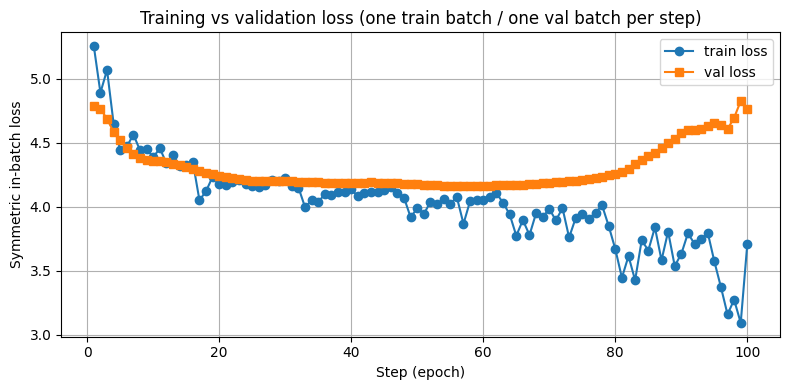

In [6]:
import matplotlib.pyplot as plt

steps = np.arange(1, len(train_loss_per_step) + 1)
plt.figure(figsize=(8, 4))
plt.plot(steps, train_loss_per_step, marker="o", label="train loss")
plt.plot(steps, val_loss_per_step, marker="s", label="val loss")
plt.title("Training vs validation loss (one train batch / one val batch per step)")
plt.xlabel("Step (epoch)")
plt.ylabel("Symmetric in-batch loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()